Epoch 001, Loss: 0.6952, Train Acc: 0.5509
Epoch 002, Loss: 0.6895, Train Acc: 0.7109
Epoch 003, Loss: 0.6836, Train Acc: 0.8321
Epoch 004, Loss: 0.6773, Train Acc: 0.9075
Epoch 005, Loss: 0.6718, Train Acc: 0.9254
Epoch 006, Loss: 0.6654, Train Acc: 0.9406
Epoch 007, Loss: 0.6586, Train Acc: 0.9451
Epoch 008, Loss: 0.6515, Train Acc: 0.9475
Epoch 009, Loss: 0.6446, Train Acc: 0.9498
Epoch 010, Loss: 0.6363, Train Acc: 0.9515
Epoch 011, Loss: 0.6296, Train Acc: 0.9489
Epoch 012, Loss: 0.6201, Train Acc: 0.9493
Epoch 013, Loss: 0.6120, Train Acc: 0.9508
Epoch 014, Loss: 0.6037, Train Acc: 0.9522
Epoch 015, Loss: 0.5944, Train Acc: 0.9533
Epoch 016, Loss: 0.5852, Train Acc: 0.9527
Epoch 017, Loss: 0.5760, Train Acc: 0.9527
Epoch 018, Loss: 0.5677, Train Acc: 0.9534
Epoch 019, Loss: 0.5585, Train Acc: 0.9537
Epoch 020, Loss: 0.5492, Train Acc: 0.9536
Epoch 021, Loss: 0.5409, Train Acc: 0.9542
Epoch 022, Loss: 0.5318, Train Acc: 0.9542
Epoch 023, Loss: 0.5213, Train Acc: 0.9540
Epoch 024, 

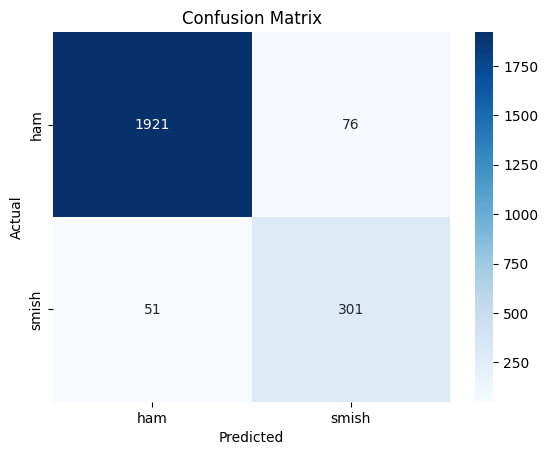

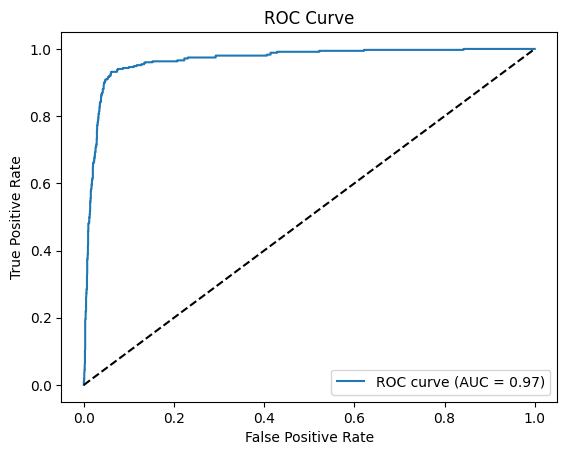

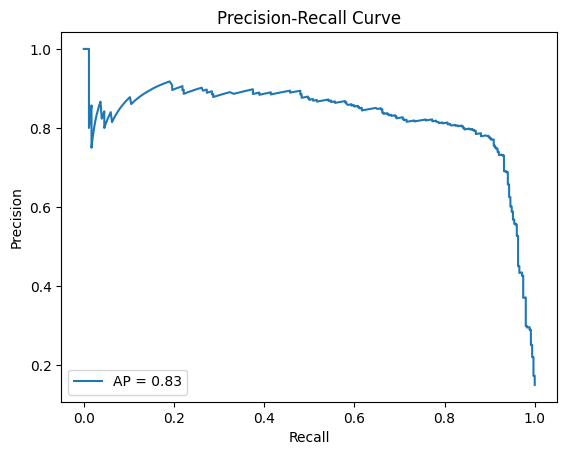

In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HypergraphConv
from torch_geometric.data import Data
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
)
import re
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load and preprocess dataset
# -----------------------------
df = pd.read_csv("Smishing_dataset1.csv")

# Text cleaning
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text

df["message"] = df["Message"].apply(clean_text)

# Encode labels (ham=0, smish=1)
le = LabelEncoder()
df["label"] = le.fit_transform(df["Labels"])

# TF-IDF features
vectorizer = TfidfVectorizer(max_features=2000)
X = vectorizer.fit_transform(df["message"]).toarray()
y = df["label"].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -----------------------------
# 2. Build Hypergraph Edges
# -----------------------------
def build_hypergraph(X, K=10):
    """
    Build hypergraph incidence matrix using KNN.
    Each node connected to its K nearest neighbors -> hyperedge.
    """
    N = X.shape[0]
    nbrs = NearestNeighbors(n_neighbors=K+1, metric="cosine").fit(X)
    _, indices = nbrs.kneighbors(X)

    edge_index = []
    for i in range(N):
        for j in indices[i]:
            edge_index.append([j, i])  # node j -> hyperedge i
    return torch.tensor(edge_index, dtype=torch.long).t()

edge_index_train = build_hypergraph(X_train, K=10)

x = torch.tensor(X_train, dtype=torch.float)
y_train_t = torch.tensor(y_train, dtype=torch.long)

data = Data(x=x, edge_index=edge_index_train, y=y_train_t)

# -----------------------------
# 3. Define HGNN Model
# -----------------------------
class HGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, dropout=0.5):
        super(HGNN, self).__init__()
        self.hconv1 = HypergraphConv(in_channels, hidden_channels)
        self.hconv2 = HypergraphConv(hidden_channels, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.hconv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.hconv2(x, edge_index)
        return x

# -----------------------------
# 4. Training
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HGNN(in_channels=X_train.shape[1], hidden_channels=64, num_classes=2).to(device)

# Class weights for imbalance
class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights)

data = data.to(device)

for epoch in range(1, 31):
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = criterion(out, data.y)
    loss.backward()
    optimizer.step()

    pred = out.argmax(dim=1)
    acc = (pred == data.y).sum().item() / data.y.size(0)
    print(f"Epoch {epoch:03d}, Loss: {loss.item():.4f}, Train Acc: {acc:.4f}")

# -----------------------------
# 5. Evaluation
# -----------------------------
edge_index_test = build_hypergraph(X_test, K=10)
data_test = Data(
    x=torch.tensor(X_test, dtype=torch.float),
    edge_index=edge_index_test,
    y=torch.tensor(y_test, dtype=torch.long)
).to(device)

model.eval()
with torch.no_grad():  # ensures no gradient tracking
    out_test = model(data_test.x, data_test.edge_index)
    probs_test = F.softmax(out_test, dim=1)[:, 1].cpu().numpy()
    pred_test = out_test.argmax(dim=1).cpu().numpy()
    true_test = data_test.y.cpu().numpy()


# Metrics
print("\nClassification Report:")
print(classification_report(true_test, pred_test, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(true_test, pred_test)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(true_test, probs_test)
roc_auc = roc_auc_score(true_test, probs_test)
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(true_test, probs_test)
avg_precision = average_precision_score(true_test, probs_test)
plt.plot(recall, precision, label=f"AP = {avg_precision:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.show()


Epoch 001 | Train Loss: 0.6962, Train Acc: 0.8414 | Val Loss: 0.6910, Val Acc: 0.8671
Epoch 002 | Train Loss: 0.6900, Train Acc: 0.8712 | Val Loss: 0.6866, Val Acc: 0.9199
Epoch 003 | Train Loss: 0.6841, Train Acc: 0.9069 | Val Loss: 0.6821, Val Acc: 0.9387
Epoch 004 | Train Loss: 0.6787, Train Acc: 0.9332 | Val Loss: 0.6774, Val Acc: 0.9432
Epoch 005 | Train Loss: 0.6726, Train Acc: 0.9432 | Val Loss: 0.6723, Val Acc: 0.9449
Epoch 006 | Train Loss: 0.6667, Train Acc: 0.9466 | Val Loss: 0.6668, Val Acc: 0.9466
Epoch 007 | Train Loss: 0.6592, Train Acc: 0.9487 | Val Loss: 0.6609, Val Acc: 0.9472
Epoch 008 | Train Loss: 0.6526, Train Acc: 0.9496 | Val Loss: 0.6547, Val Acc: 0.9478
Epoch 009 | Train Loss: 0.6453, Train Acc: 0.9498 | Val Loss: 0.6482, Val Acc: 0.9483
Epoch 010 | Train Loss: 0.6373, Train Acc: 0.9501 | Val Loss: 0.6414, Val Acc: 0.9483
Epoch 011 | Train Loss: 0.6297, Train Acc: 0.9498 | Val Loss: 0.6344, Val Acc: 0.9489
Epoch 012 | Train Loss: 0.6215, Train Acc: 0.9507 | Va

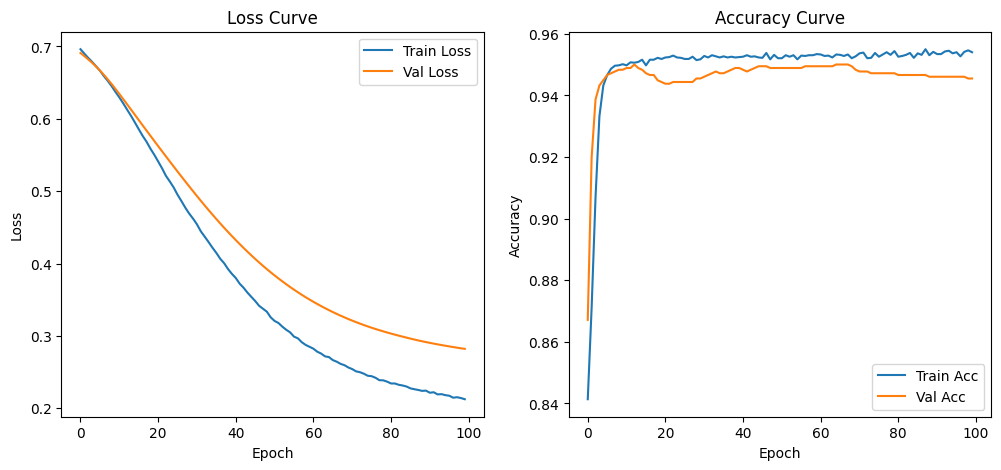


Final Test Metrics:
Accuracy:  0.9393
Precision: 0.7918
Recall:    0.8068
F1-score:  0.7992

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      0.96      0.96      1498
       smish       0.79      0.81      0.80       264

    accuracy                           0.94      1762
   macro avg       0.88      0.88      0.88      1762
weighted avg       0.94      0.94      0.94      1762



In [7]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HypergraphConv
from torch_geometric.data import Data
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)
import re
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load and preprocess dataset
# -----------------------------
df = pd.read_csv("Smishing_dataset1.csv")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text

df["message"] = df["Message"].apply(clean_text)

# Encode labels
le = LabelEncoder()
df["label"] = le.fit_transform(df["Labels"])

# TF-IDF
vectorizer = TfidfVectorizer(max_features=2000)
X = vectorizer.fit_transform(df["message"]).toarray()
y = df["label"].values

# Split -> train/val/test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# -----------------------------
# 2. Build Hypergraph Edges
# -----------------------------
def build_hypergraph(X, K=10):
    N = X.shape[0]
    nbrs = NearestNeighbors(n_neighbors=K+1, metric="cosine").fit(X)
    _, indices = nbrs.kneighbors(X)
    edge_index = []
    for i in range(N):
        for j in indices[i]:
            edge_index.append([j, i])  # node j -> hyperedge i
    return torch.tensor(edge_index, dtype=torch.long).t()

def make_data(X, y, K=10):
    edge_index = build_hypergraph(X, K)
    return Data(
        x=torch.tensor(X, dtype=torch.float),
        edge_index=edge_index,
        y=torch.tensor(y, dtype=torch.long)
    )

data_train = make_data(X_train, y_train, K=10)
data_val   = make_data(X_val, y_val, K=10)
data_test  = make_data(X_test, y_test, K=10)

# -----------------------------
# 3. HGNN Model
# -----------------------------
class HGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, dropout=0.5):
        super(HGNN, self).__init__()
        self.hconv1 = HypergraphConv(in_channels, hidden_channels)
        self.hconv2 = HypergraphConv(hidden_channels, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.hconv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.hconv2(x, edge_index)
        return x

# -----------------------------
# 4. Training Loop (with validation)
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HGNN(in_channels=X_train.shape[1], hidden_channels=64, num_classes=2).to(device)

class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights)

data_train, data_val, data_test = data_train.to(device), data_val.to(device), data_test.to(device)

train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(1, 101):
    # ---- Training ----
    model.train()
    optimizer.zero_grad()
    out = model(data_train.x, data_train.edge_index)
    loss = criterion(out, data_train.y)
    loss.backward()
    optimizer.step()

    pred = out.argmax(dim=1)
    acc = (pred == data_train.y).sum().item() / data_train.y.size(0)

    # ---- Validation ----
    model.eval()
    with torch.no_grad():
        out_val = model(data_val.x, data_val.edge_index)
        val_loss = criterion(out_val, data_val.y).item()
        val_pred = out_val.argmax(dim=1)
        val_acc = (val_pred == data_val.y).sum().item() / data_val.y.size(0)

    train_losses.append(loss.item())
    val_losses.append(val_loss)
    train_accs.append(acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch:03d} | Train Loss: {loss.item():.4f}, Train Acc: {acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# -----------------------------
# 5. Plot Training vs Validation
# -----------------------------
plt.figure(figsize=(12,5))

# Loss curve
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Accuracy curve
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

# -----------------------------
# 6. Final Evaluation on Test Set
# -----------------------------
model.eval()
with torch.no_grad():
    out_test = model(data_test.x, data_test.edge_index)
    pred_test = out_test.argmax(dim=1).cpu().numpy()
    true_test = data_test.y.cpu().numpy()

# Metrics
acc = accuracy_score(true_test, pred_test)
prec = precision_score(true_test, pred_test)
rec = recall_score(true_test, pred_test)
f1 = f1_score(true_test, pred_test)

print("\nFinal Test Metrics:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(true_test, pred_test, target_names=le.classes_))


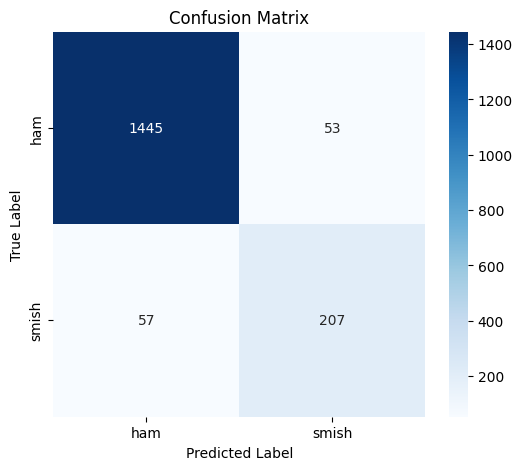


Classification Report:
              precision    recall  f1-score   support

         ham       0.96      0.96      0.96      1498
       smish       0.80      0.78      0.79       264

    accuracy                           0.94      1762
   macro avg       0.88      0.87      0.88      1762
weighted avg       0.94      0.94      0.94      1762



In [4]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(true_test, pred_test)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Classification Report (already printed, but printing again for clarity)
print("\nClassification Report:")
print(classification_report(true_test, pred_test, target_names=le.classes_))


Epoch 001 | Train Loss: 0.6909, Train Acc: 0.1966 | Val Loss: 0.6880, Val Acc: 0.4850
Epoch 002 | Train Loss: 0.6854, Train Acc: 0.4403 | Val Loss: 0.6833, Val Acc: 0.8807
Epoch 003 | Train Loss: 0.6787, Train Acc: 0.7808 | Val Loss: 0.6784, Val Acc: 0.9233
Epoch 004 | Train Loss: 0.6723, Train Acc: 0.8939 | Val Loss: 0.6731, Val Acc: 0.9353
Epoch 005 | Train Loss: 0.6658, Train Acc: 0.9168 | Val Loss: 0.6674, Val Acc: 0.9466
Epoch 006 | Train Loss: 0.6594, Train Acc: 0.9274 | Val Loss: 0.6612, Val Acc: 0.9455
Epoch 007 | Train Loss: 0.6516, Train Acc: 0.9395 | Val Loss: 0.6546, Val Acc: 0.9443
Epoch 008 | Train Loss: 0.6436, Train Acc: 0.9427 | Val Loss: 0.6477, Val Acc: 0.9455
Epoch 009 | Train Loss: 0.6347, Train Acc: 0.9438 | Val Loss: 0.6405, Val Acc: 0.9455
Epoch 010 | Train Loss: 0.6265, Train Acc: 0.9477 | Val Loss: 0.6332, Val Acc: 0.9455
Epoch 011 | Train Loss: 0.6178, Train Acc: 0.9456 | Val Loss: 0.6256, Val Acc: 0.9449
Epoch 012 | Train Loss: 0.6096, Train Acc: 0.9488 | Va

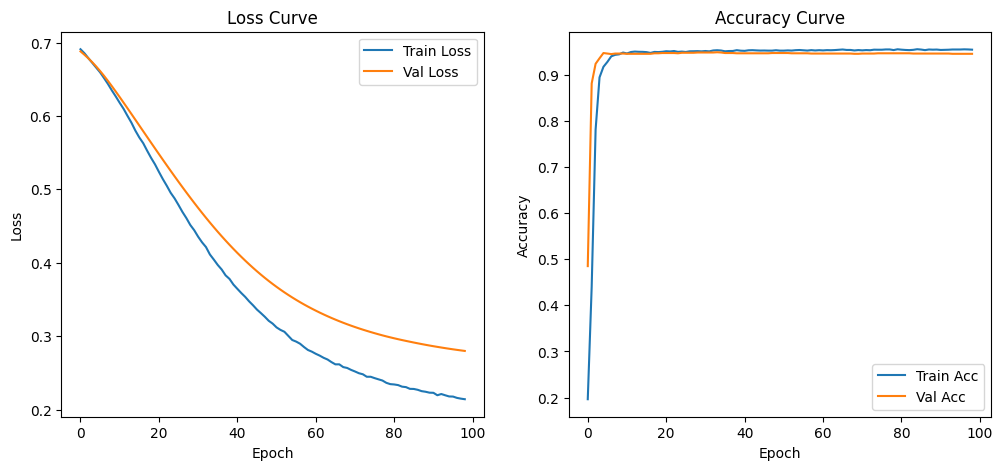


Final Test Metrics:
Accuracy:  0.9404
Precision: 0.7870
Recall:    0.8258
F1-score:  0.8059

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      0.96      0.96      1498
       smish       0.79      0.83      0.81       264

    accuracy                           0.94      1762
   macro avg       0.88      0.89      0.89      1762
weighted avg       0.94      0.94      0.94      1762



In [5]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HypergraphConv
from torch_geometric.data import Data
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import re
import matplotlib.pyplot as plt

# -----------------------------
# 1. Load and preprocess dataset
# -----------------------------
df = pd.read_csv("Smishing_dataset1.csv")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text

df["message"] = df["Message"].apply(clean_text)

# Encode labels
le = LabelEncoder()
df["label"] = le.fit_transform(df["Labels"])

# TF-IDF
vectorizer = TfidfVectorizer(max_features=2000)
X = vectorizer.fit_transform(df["message"]).toarray()
y = df["label"].values

# Split into train/val/test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

# -----------------------------
# 2. Hypergraph Builder
# -----------------------------
def build_hypergraph(X, K=10):
    N = X.shape[0]
    nbrs = NearestNeighbors(n_neighbors=K+1, metric="cosine").fit(X)
    _, indices = nbrs.kneighbors(X)
    edge_index = []
    for i in range(N):
        for j in indices[i]:
            edge_index.append([j, i])  # node j -> hyperedge i
    return torch.tensor(edge_index, dtype=torch.long).t()

def make_data(X, y, K=10):
    edge_index = build_hypergraph(X, K)
    return Data(x=torch.tensor(X, dtype=torch.float),
                edge_index=edge_index,
                y=torch.tensor(y, dtype=torch.long))

data_train, data_val, data_test = make_data(X_train, y_train), make_data(X_val, y_val), make_data(X_test, y_test)

# -----------------------------
# 3. HGNN Model
# -----------------------------
class HGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, dropout=0.5):
        super(HGNN, self).__init__()
        self.hconv1 = HypergraphConv(in_channels, hidden_channels)
        self.hconv2 = HypergraphConv(hidden_channels, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.hconv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.hconv2(x, edge_index)
        return x

# -----------------------------
# 4. Training with Early Stopping
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HGNN(in_channels=X_train.shape[1], hidden_channels=64, num_classes=2).to(device)

class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights)

data_train, data_val, data_test = data_train.to(device), data_val.to(device), data_test.to(device)

train_losses, val_losses, train_accs, val_accs = [], [], [], []
best_val_loss = float("inf")
patience, patience_counter = 5, 0  # Early stopping patience
best_model_state = None

for epoch in range(1, 100):  # allow more epochs, early stopping will cut it short
    # ---- Training ----
    model.train()
    optimizer.zero_grad()
    out = model(data_train.x, data_train.edge_index)
    loss = criterion(out, data_train.y)
    loss.backward()
    optimizer.step()

    pred = out.argmax(dim=1)
    acc = (pred == data_train.y).sum().item() / data_train.y.size(0)

    # ---- Validation ----
    model.eval()
    with torch.no_grad():
        out_val = model(data_val.x, data_val.edge_index)
        val_loss = criterion(out_val, data_val.y).item()
        val_pred = out_val.argmax(dim=1)
        val_acc = (val_pred == data_val.y).sum().item() / data_val.y.size(0)

    train_losses.append(loss.item())
    val_losses.append(val_loss)
    train_accs.append(acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch:03d} | Train Loss: {loss.item():.4f}, Train Acc: {acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # ---- Early Stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = model.state_dict()
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

# Load best model
model.load_state_dict(best_model_state)

# -----------------------------
# 5. Plot Learning Curves
# -----------------------------
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()
plt.show()

# -----------------------------
# 6. Final Evaluation on Test Set
# -----------------------------
model.eval()
with torch.no_grad():
    out_test = model(data_test.x, data_test.edge_index)
    pred_test = out_test.argmax(dim=1).cpu().numpy()
    true_test = data_test.y.cpu().numpy()

# Metrics
acc = accuracy_score(true_test, pred_test)
prec = precision_score(true_test, pred_test)
rec = recall_score(true_test, pred_test)
f1 = f1_score(true_test, pred_test)

print("\nFinal Test Metrics:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(true_test, pred_test, target_names=le.classes_))


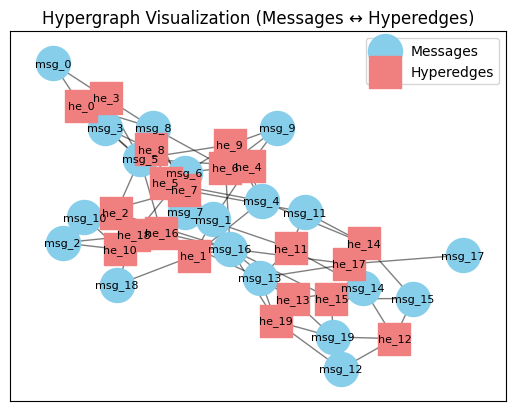


Message Mapping:
msg_0: i accidentally brought em home in the box...
msg_1: how much would it cost to hire a hitman...
msg_2: i think that tantrums finished so yeah ill be by at some poi...
msg_3: send me the new number...
msg_4: friendship is not a game to play it is not a word to say it ...
msg_5: hey do u fancy meetin me at 4 at cha  hav a lil beverage on ...
msg_6: i want to sent  ltgt mesages today thats y sorry if i hurts...
msg_7: yo come over carlos will be here soon...
msg_8: ki will send in  ltgt  min...
msg_9: rajipls do me a favour pls convey my birthday wishes to nimy...
msg_10: well im going to be an aunty...
msg_11: ela kanoil download come wen ur free...
msg_12: wah okie okie muz make use of e unlimited haha ...
msg_13: where are you lover  i need you ...
msg_14: a cute thought for friendship its not necessary to share eve...
msg_15: free2day sexy st georges day pic of jordantxt pic to 89080 d...
msg_16: oops sorry just to check that you dont mind picking me up to...
m

In [6]:
import pandas as pd
import re
import torch
import networkx as nx
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

# -----------------------------
# 1. Load + Clean Dataset
# -----------------------------
df = pd.read_csv("Smishing_dataset1.csv")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text

df["message"] = df["Message"].apply(clean_text)

# Pick a small sample (20 messages for visualization)
sample_df = df.sample(20, random_state=42).reset_index(drop=True)

# -----------------------------
# 2. TF-IDF + Build Hypergraph
# -----------------------------
vectorizer = TfidfVectorizer(max_features=500)
X = vectorizer.fit_transform(sample_df["message"]).toarray()

def build_hypergraph_edges(X, K=3):
    N = X.shape[0]
    nbrs = NearestNeighbors(n_neighbors=K+1, metric="cosine").fit(X)
    _, indices = nbrs.kneighbors(X)

    edges = []
    for i in range(N):
        for j in indices[i]:
            edges.append((f"msg_{j}", f"he_{i}"))  # msg = node, he = hyperedge
    return edges

edges = build_hypergraph_edges(X, K=3)

# -----------------------------
# 3. Build Graph in NetworkX
# -----------------------------
G = nx.Graph()
# Add message nodes (blue)
for i, msg in enumerate(sample_df["message"]):
    G.add_node(f"msg_{i}", label=f"msg_{i}", type="message", text=msg)

# Add hyperedge nodes (red)
for i in range(len(sample_df)):
    G.add_node(f"he_{i}", label=f"he_{i}", type="hyperedge")

# Add edges
G.add_edges_from(edges)

# -----------------------------
# 4. Draw Graph
# -----------------------------
pos = nx.spring_layout(G, seed=42)

# Draw nodes
msg_nodes = [n for n, d in G.nodes(data=True) if d["type"] == "message"]
he_nodes = [n for n, d in G.nodes(data=True) if d["type"] == "hyperedge"]

nx.draw_networkx_nodes(G, pos, nodelist=msg_nodes, node_color="skyblue", node_size=600, label="Messages")
nx.draw_networkx_nodes(G, pos, nodelist=he_nodes, node_color="lightcoral", node_shape="s", node_size=500, label="Hyperedges")

# Draw edges
nx.draw_networkx_edges(G, pos, alpha=0.5)

# Labels (just node names for clarity)
nx.draw_networkx_labels(G, pos, font_size=8)

plt.title("Hypergraph Visualization (Messages ↔ Hyperedges)")
plt.legend(scatterpoints=1)
plt.show()

# -----------------------------
# 5. Print Message Mapping
# -----------------------------
print("\nMessage Mapping:")
for i, msg in enumerate(sample_df["message"]):
    print(f"msg_{i}: {msg[:60]}...")


Epoch 001 | Train Loss: 0.6920, Train Acc: 0.4580 | Val Loss: 0.6871, Val Acc: 0.9216
Epoch 002 | Train Loss: 0.6855, Train Acc: 0.7982 | Val Loss: 0.6821, Val Acc: 0.9443
Epoch 003 | Train Loss: 0.6795, Train Acc: 0.9109 | Val Loss: 0.6769, Val Acc: 0.9438
Epoch 004 | Train Loss: 0.6726, Train Acc: 0.9366 | Val Loss: 0.6712, Val Acc: 0.9461
Epoch 005 | Train Loss: 0.6656, Train Acc: 0.9444 | Val Loss: 0.6652, Val Acc: 0.9455
Epoch 006 | Train Loss: 0.6583, Train Acc: 0.9484 | Val Loss: 0.6589, Val Acc: 0.9461
Epoch 007 | Train Loss: 0.6506, Train Acc: 0.9472 | Val Loss: 0.6523, Val Acc: 0.9466
Epoch 008 | Train Loss: 0.6432, Train Acc: 0.9502 | Val Loss: 0.6455, Val Acc: 0.9461
Epoch 009 | Train Loss: 0.6349, Train Acc: 0.9493 | Val Loss: 0.6385, Val Acc: 0.9466
Epoch 010 | Train Loss: 0.6264, Train Acc: 0.9499 | Val Loss: 0.6314, Val Acc: 0.9472
Epoch 011 | Train Loss: 0.6172, Train Acc: 0.9509 | Val Loss: 0.6241, Val Acc: 0.9472
Epoch 012 | Train Loss: 0.6090, Train Acc: 0.9519 | Va

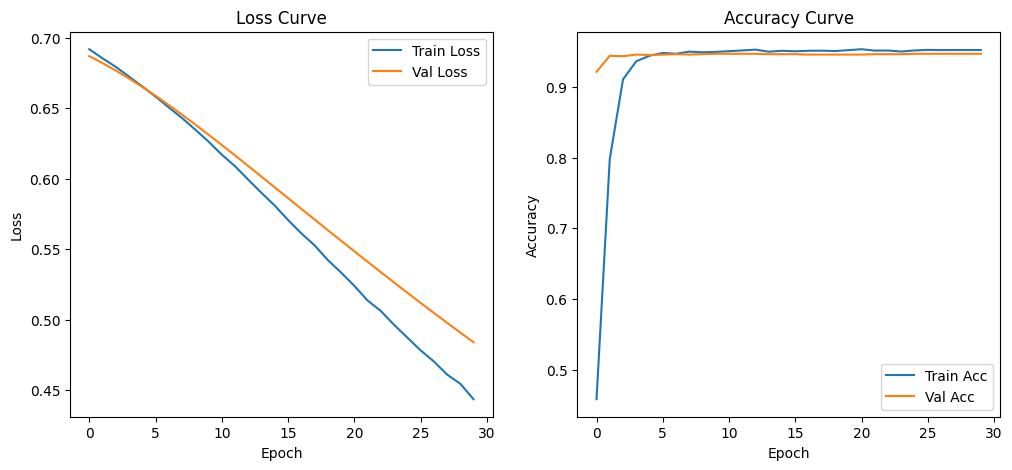


Final Test Metrics:
Accuracy:  0.9398
Precision: 0.8110
Recall:    0.7803
F1-score:  0.7954

Classification Report:
              precision    recall  f1-score   support

         ham       0.96      0.97      0.96      1498
       smish       0.81      0.78      0.80       264

    accuracy                           0.94      1762
   macro avg       0.89      0.87      0.88      1762
weighted avg       0.94      0.94      0.94      1762



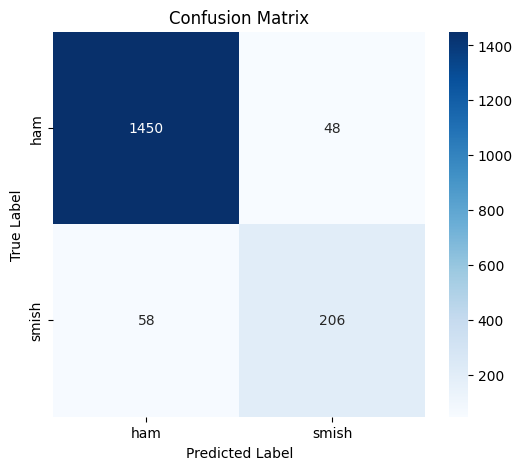

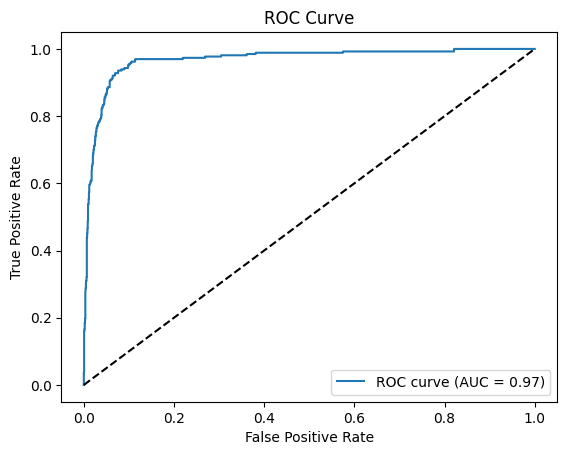

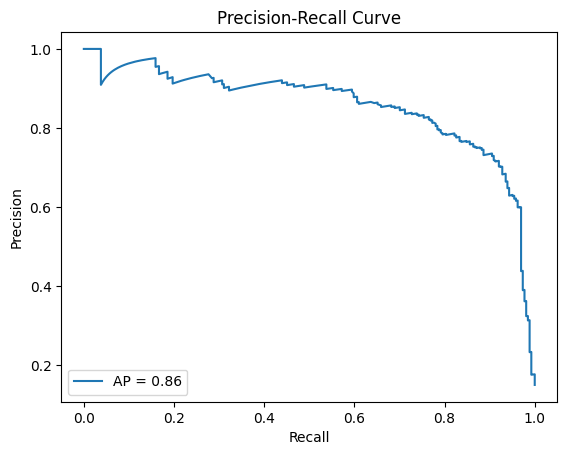


Model and preprocessing files saved: hgnn_smish_model.pth, tfidf_vectorizer.pkl, label_encoder.pkl


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import HypergraphConv
from torch_geometric.data import Data
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score
)
import re
import matplotlib.pyplot as plt
import seaborn as sns
import joblib  # for saving preprocessing objects

# -----------------------------
# 1. Load and preprocess dataset
# -----------------------------
df = pd.read_csv("Smishing_dataset1.csv")

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
    text = re.sub(r"[^a-z0-9\s]", "", text)
    return text

df["message"] = df["Message"].apply(clean_text)

# Encode labels
le = LabelEncoder()
df["label"] = le.fit_transform(df["Labels"])

# TF-IDF
vectorizer = TfidfVectorizer(max_features=2000)
X = vectorizer.fit_transform(df["message"]).toarray()
y = df["label"].values

# Split -> train/val/test
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

# -----------------------------
# 2. Build Hypergraph Edges
# -----------------------------
def build_hypergraph(X, K=10):
    N = X.shape[0]
    nbrs = NearestNeighbors(n_neighbors=K+1, metric="cosine").fit(X)
    _, indices = nbrs.kneighbors(X)
    edge_index = []
    for i in range(N):
        for j in indices[i]:
            edge_index.append([j, i])  # node j -> hyperedge i
    return torch.tensor(edge_index, dtype=torch.long).t()

def make_data(X, y, K=10):
    edge_index = build_hypergraph(X, K)
    return Data(
        x=torch.tensor(X, dtype=torch.float),
        edge_index=edge_index,
        y=torch.tensor(y, dtype=torch.long)
    )

data_train = make_data(X_train, y_train, K=10)
data_val   = make_data(X_val, y_val, K=10)
data_test  = make_data(X_test, y_test, K=10)

# -----------------------------
# 3. HGNN Model
# -----------------------------
class HGNN(nn.Module):
    def __init__(self, in_channels, hidden_channels, num_classes, dropout=0.5):
        super(HGNN, self).__init__()
        self.hconv1 = HypergraphConv(in_channels, hidden_channels)
        self.hconv2 = HypergraphConv(hidden_channels, num_classes)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.hconv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.hconv2(x, edge_index)
        return x

# -----------------------------
# 4. Training Loop (with validation)
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = HGNN(in_channels=X_train.shape[1], hidden_channels=64, num_classes=2).to(device)

class_weights = compute_class_weight(class_weight="balanced", classes=np.unique(y_train), y=y_train)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = nn.CrossEntropyLoss(weight=class_weights)

data_train, data_val, data_test = data_train.to(device), data_val.to(device), data_test.to(device)

train_losses, val_losses, train_accs, val_accs = [], [], [], []

for epoch in range(1, 31):
    # ---- Training ----
    model.train()
    optimizer.zero_grad()
    out = model(data_train.x, data_train.edge_index)
    loss = criterion(out, data_train.y)
    loss.backward()
    optimizer.step()

    pred = out.argmax(dim=1)
    acc = (pred == data_train.y).sum().item() / data_train.y.size(0)

    # ---- Validation ----
    model.eval()
    with torch.no_grad():
        out_val = model(data_val.x, data_val.edge_index)
        val_loss = criterion(out_val, data_val.y).item()
        val_pred = out_val.argmax(dim=1)
        val_acc = (val_pred == data_val.y).sum().item() / data_val.y.size(0)

    train_losses.append(loss.item())
    val_losses.append(val_loss)
    train_accs.append(acc)
    val_accs.append(val_acc)

    print(f"Epoch {epoch:03d} | Train Loss: {loss.item():.4f}, Train Acc: {acc:.4f} | Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# -----------------------------
# 5. Plot Training vs Validation
# -----------------------------
plt.figure(figsize=(12,5))

# Loss curve
plt.subplot(1,2,1)
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss Curve")
plt.legend()

# Accuracy curve
plt.subplot(1,2,2)
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy Curve")
plt.legend()

plt.show()

# -----------------------------
# 6. Final Evaluation on Test Set
# -----------------------------
model.eval()
with torch.no_grad():
    out_test = model(data_test.x, data_test.edge_index)
    probs_test = F.softmax(out_test, dim=1)[:, 1].cpu().numpy()
    pred_test = out_test.argmax(dim=1).cpu().numpy()
    true_test = data_test.y.cpu().numpy()

# Metrics
acc = accuracy_score(true_test, pred_test)
prec = precision_score(true_test, pred_test)
rec = recall_score(true_test, pred_test)
f1 = f1_score(true_test, pred_test)

print("\nFinal Test Metrics:")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")

print("\nClassification Report:")
print(classification_report(true_test, pred_test, target_names=le.classes_))

# -----------------------------
# 7. Confusion Matrix
# -----------------------------
cm = confusion_matrix(true_test, pred_test)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# -----------------------------
# 8. ROC Curve
# -----------------------------
fpr, tpr, _ = roc_curve(true_test, probs_test)
roc_auc = roc_auc_score(true_test, probs_test)
plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

# -----------------------------
# 9. Precision-Recall Curve
# -----------------------------
precision, recall, _ = precision_recall_curve(true_test, probs_test)
avg_precision = average_precision_score(true_test, probs_test)
plt.plot(recall, precision, label=f"AP = {avg_precision:.2f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend(loc="lower left")
plt.show()

# -----------------------------
# 10. Save Model and Preprocessing Files
# -----------------------------
torch.save(model.state_dict(), "hgnn_smish_model.pth")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")
joblib.dump(le, "label_encoder.pkl")

print("\nModel and preprocessing files saved: hgnn_smish_model.pth, tfidf_vectorizer.pkl, label_encoder.pkl")
